In [5]:
import os
target_path = '/users/lorin.ng/SURIP2026/data'
os.chdir(target_path)
print(f"current directory: {os.getcwd()}")

current directory: /users/lorin.ng/SURIP2026/data


In [4]:
import pandas as pd
file = "processed_samples/MD_SDSS_l2_1_0_bilby_style_samples.h5"
df = pd.read_hdf(file, key='df')
print(df.shape)
print(df.columns)

(11329, 39)
Index(['mass_1', 'mass_2', 'spin_1z', 'spin_2z', 'iota', 'luminosity_distance',
       'ra', 'dec', 'phase', 'psi', 'geocent_time', 'lnlike', 'spin_1x',
       'spin_1y', 'spin_2x', 'spin_2y', 'theta_jn', 'a_1', 'a_2', 'tilt_1',
       'tilt_2', 'phi_12', 'phi_jl', 'mass_ratio', 'chirp_mass',
       'cos_theta_jn', 'sin_dec', 'chi_eff', 'chi_1_in_plane',
       'chi_2_in_plane', 'chi_p', 'network_optimal_snr', 'log_likelihood',
       'total_mass', 'redshift', 'mass_1_source', 'mass_2_source',
       'chirp_mass_source', 'total_mass_source'],
      dtype='object')


In [5]:
import pandas as pd
file = "o4b_events.csv"
df = pd.read_csv(file)
print(df.columns)
print(df.shape)

Index(['id', 'commonName', 'version', 'catalog.shortName', 'GPS', 'reference',
       'jsonurl', 'mass_1_source', 'mass_1_source_lower',
       'mass_1_source_upper', 'mass_2_source', 'mass_2_source_lower',
       'mass_2_source_upper', 'network_matched_filter_snr',
       'network_matched_filter_snr_lower', 'network_matched_filter_snr_upper',
       'luminosity_distance', 'luminosity_distance_lower',
       'luminosity_distance_upper', 'chi_eff', 'chi_eff_lower',
       'chi_eff_upper', 'total_mass_source', 'total_mass_source_lower',
       'total_mass_source_upper', 'chirp_mass_source',
       'chirp_mass_source_lower', 'chirp_mass_source_upper', 'chirp_mass',
       'chirp_mass_lower', 'chirp_mass_upper', 'redshift', 'redshift_lower',
       'redshift_upper', 'far', 'far_lower', 'far_upper', 'p_astro',
       'p_astro_lower', 'p_astro_upper', 'final_mass_source',
       'final_mass_source_lower', 'final_mass_source_upper'],
      dtype='object')
(161, 43)


In [12]:
from itertools import combinations
import pandas as pd

# 1. 篩選高質量的 BBH 事件（例如 SNR > 10，減少噪訊干擾）
df_high_snr = df[df['network_matched_filter_snr'] > 10].copy()

# 2. 建立所有事件的兩兩組合
pairs = list(combinations(df_high_snr.index, 2))
results = []

for i, j in pairs:
    e1 = df_high_snr.loc[i]
    e2 = df_high_snr.loc[j]
    
    # 計算 Chirp Mass 的百分比差異
    # 透鏡對的 Chirp Mass 應該幾乎完全相同
    m_diff = abs(e1['chirp_mass_source'] - e2['chirp_mass_source'])
    m_avg = (e1['chirp_mass_source'] + e2['chirp_mass_source']) / 2
    percent_diff = (m_diff / m_avg) * 100
    
    # 計算時間間隔 (秒轉為天)
    time_delay = abs(e1['GPS'] - e2['GPS']) / 86400
    
    results.append({
        'Event_1': e1['commonName'],
        'Event_2': e2['commonName'],
        'M_chirp_1': e1['chirp_mass_source'],
        'M_chirp_2': e2['chirp_mass_source'],
        'Diff_%': round(percent_diff, 3),
        'Time_Delay_Days': round(time_delay, 1)
    })

# 3. 找出質量差異最小的前 10 名
candidates = pd.DataFrame(results).sort_values(by='Diff_%')
print("--- 潛在透鏡候選對 (按 Chirp Mass 相似度排序) ---")
print(candidates.head(10).to_string(index=False))


--- 潛在透鏡候選對 (按 Chirp Mass 相似度排序) ---
        Event_1         Event_2  M_chirp_1  M_chirp_2  Diff_%  Time_Delay_Days
GW240922_142106 GW241102_124058       8.12       8.12   0.000             40.9
GW240511_031507 GW240621_200935      31.10      31.10   0.000             41.7
GW240919_061559 GW250118_170523      29.00      29.00   0.000            121.5
GW240825_055146 GW241009_084816       8.77       8.78   0.114             45.1
GW240915_105151 GW241231_054133       8.07       8.08   0.124            106.8
GW240920_073424 GW240921_201835      15.60      15.62   0.128              1.5
GW240923_204006 GW240924_000316      34.10      34.20   0.293              0.1
GW240923_204006 GW241116_151753      34.10      34.00   0.294             53.8
GW241116_151753 GW250104_015122      34.00      33.90   0.295             48.4
GW241002_030559 GW250114_082203      28.80      28.71   0.313            104.2


/tmp/ipykernel_1654569/982353314.py:24: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('plasma_r')


Plot saved as 'logB_comparison.png' in the '../plots/'.


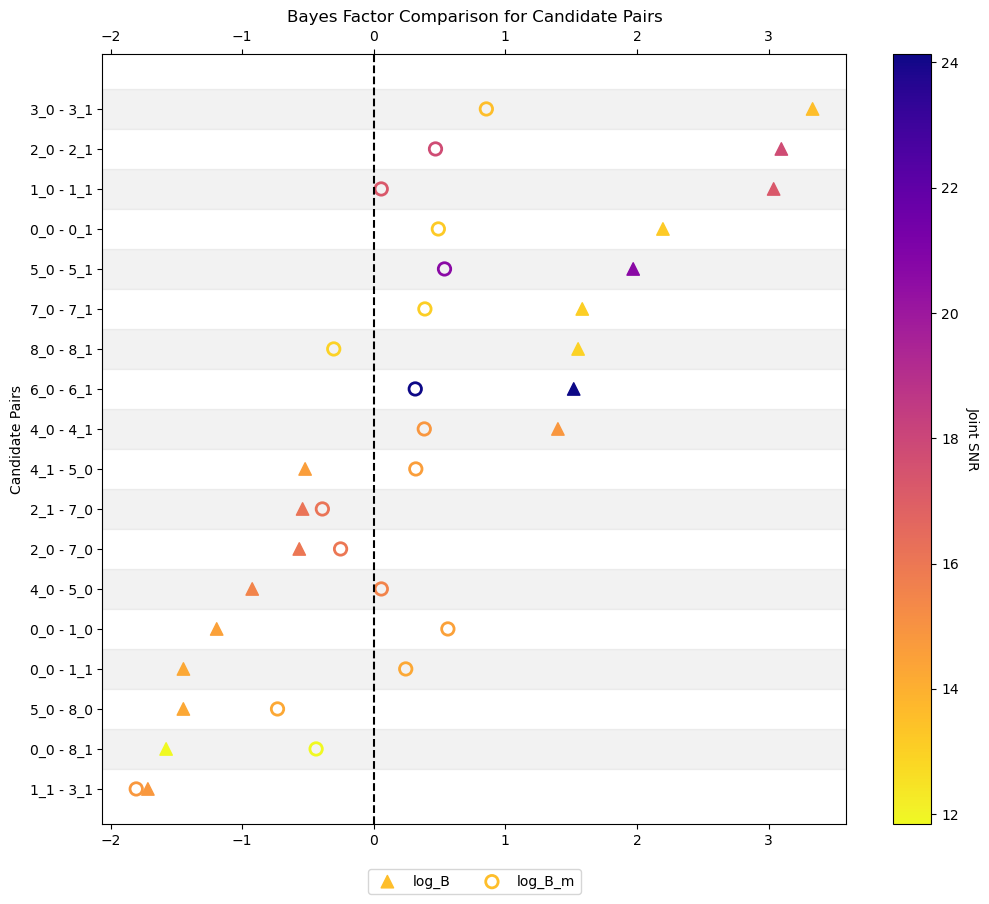

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from matplotlib.colors import Normalize
import matplotlib.cm as cm

df_logB = pd.read_csv("../plots/bayes_factor_3d_results.csv")
df_SNR = pd.read_csv("../plots/joint_SNR.csv")
for df in [df_logB, df_SNR]:
    df['Pair_0'] = df['Pair_0'].astype(str)
    df['Pair_1'] = df['Pair_1'].astype(str)
df = pd.merge(df_logB, df_SNR, on=['Pair_0', 'Pair_1'], how='inner')

df = df[(df['log_B'] > -2) & (df['log_B_m'] > -2)].sort_values(by='log_B', ascending=False)
y_pos = np.arange(len(df))
df['pair label'] = df['Pair_0'] + " - " + df['Pair_1']

fig, ax = plt.subplots(figsize=(12, 10))
for i in range(len(df)):
    if i % 2 == 0:
        ax.axhspan(i - 0.5, i + 0.5, color='gray', alpha=0.1, zorder=0)

norm = Normalize(vmin=df['Joint_SNR'].min(), vmax=df['Joint_SNR'].max())
cmap = cm.get_cmap('plasma_r')
edge_colors = [cmap(norm(v)) for v in df['Joint_SNR']]
sc = ax.scatter(df['log_B'], y_pos, marker='^', c=df['Joint_SNR'], cmap='plasma_r', s=80, label='log_B')
ax.scatter(df['log_B_m'], y_pos, marker='o', facecolor='none', edgecolors=edge_colors, linewidths=2, s=80, label='log_B_m') 

ax.set_yticks(y_pos)
ax.set_ylabel('Candidate Pairs')
ax.set_yticklabels(df['pair label'])
ax.invert_yaxis()
ax.xaxis.set_label_position('top')
ax.tick_params(axis='x', top=True, bottom=True, labeltop=True, labelbottom=True)
ax.axvline(x=0, color='black', linestyle='--',zorder=1)

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('Joint SNR', rotation=270, labelpad=15)

ax.set_title('Bayes Factor Comparison for Candidate Pairs')
ax.legend(loc='lower center', bbox_to_anchor=(0.5, -0.1), ncol=2, frameon=True, fontsize=10)

plt.savefig("../plots/logB_3d_comparison.png", dpi=300)
print("Plot saved as 'logB_3d_comparison.png' in the '../plots/'.")

/tmp/ipykernel_1654569/995117806.py:25: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('plasma_r')


Plot saved as 'logB_vertical_comparison.png'.


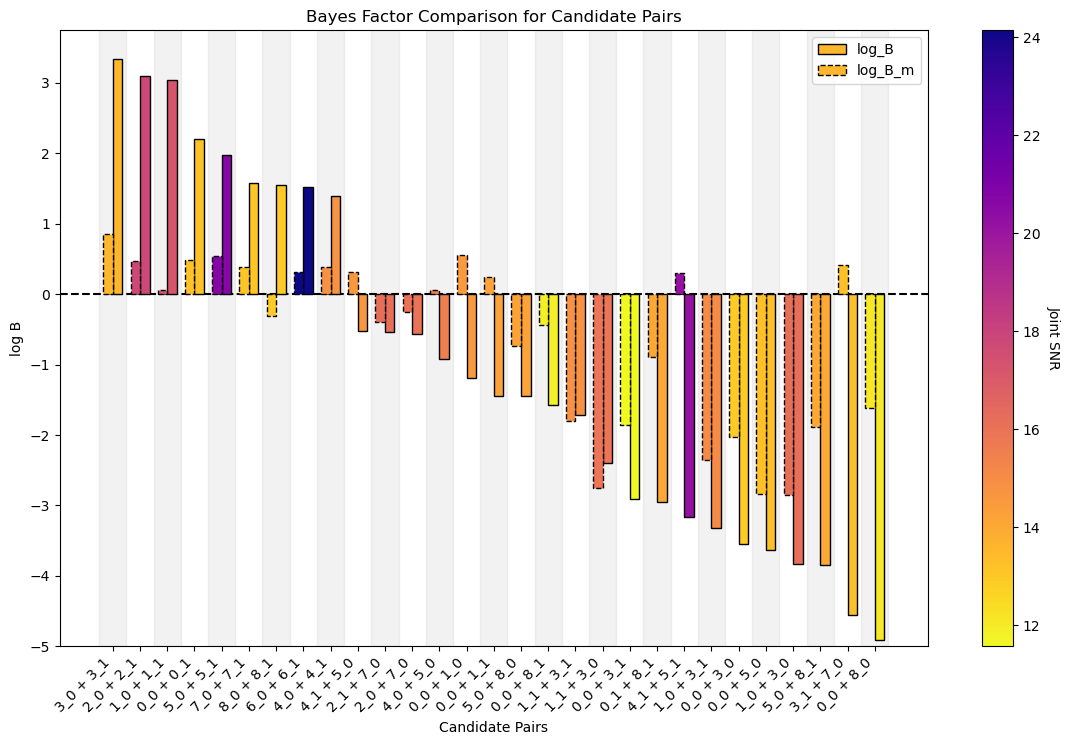

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from matplotlib.colors import Normalize
import matplotlib.cm as cm
a = -5

df_logB = pd.read_csv("../plots/bayes_factor_results.csv")
df_SNR = pd.read_csv("../plots/joint_SNR.csv")
for df in [df_logB, df_SNR]:
    df['Pair_0'] = df['Pair_0'].astype(str)
    df['Pair_1'] = df['Pair_1'].astype(str)
df = pd.merge(df_logB, df_SNR, on=['Pair_0', 'Pair_1'], how='inner')

df = df[(df['log_B'] > a) & (df['log_B_m'] > a)].sort_values(by='log_B', ascending=False)
x_pos = np.arange(len(df)) 
width = 0.35 # 柱子寬度
df['pair label'] = df['Pair_0'] + " + " + df['Pair_1']
fig, ax = plt.subplots(figsize=(14, 8)) 
for i in range(len(df)):
    if i % 2 == 0:
        ax.axvspan(i - 0.5, i + 0.5, color='gray', alpha=0.1, zorder=0)

norm = Normalize(vmin=df['Joint_SNR'].min(), vmax=df['Joint_SNR'].max())
cmap = cm.get_cmap('plasma_r')
bar_colors = [cmap(norm(v)) for v in df['Joint_SNR']]

sc = ax.bar(x_pos + width/2, df['log_B'], width, color=bar_colors, edgecolor='black', label='log_B', zorder=3)
ax.bar(x_pos - width/2, df['log_B_m'], width, color=bar_colors, edgecolor='black', linestyle='--',linewidth=1, label='log_B_m', zorder=3)
ax.set_xticks(x_pos)
ax.set_xticklabels(df['pair label'], rotation=45, ha='right')
ax.set_xlabel('Candidate Pairs')
ax.set_ylabel('log B')
ax.set_ylim(bottom=a)
ax.axhline(y=0, color='black', linestyle='--', zorder=1)

sm = cm.ScalarMappable(cmap=cmap, norm=norm)
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label('Joint SNR', rotation=270, labelpad=15)

ax.set_title('Bayes Factor Comparison for Candidate Pairs')
ax.legend(loc='upper right', frameon=True, fontsize=10)

plt.savefig("../plots/logB_vertical_3d_comparison.png", dpi=300)
print("Plot saved as 'logB_vertical_3d_comparison.png' in the '../plots/'.")

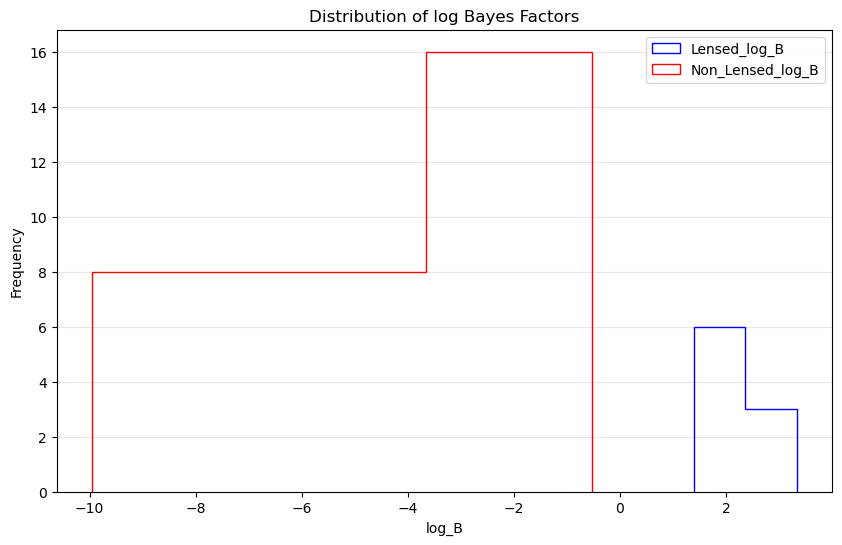

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
a= -10
df = pd.read_csv('../plots/bayes_factor_3d_results.csv')
df = df[(df['log_B'] > a) & (df['log_B_m'] > a)]

def lensed(row):
    prefix_0 = row['Pair_0'].split('_')[0]
    prefix_1 = row['Pair_1'].split('_')[0]

    return prefix_0 == prefix_1

df['lensed'] = df.apply(lensed, axis=1)
lensed_log_B = df[df['lensed'] == True]['log_B']
non_lensed_log_B = df[df['lensed'] == False]['log_B']

plt.figure(figsize=(10, 6))
plt.hist(lensed_log_B, bins=2, label='Lensed_log_B', color='blue',histtype='step')
plt.hist(non_lensed_log_B, bins=3, label='Non_Lensed_log_B', color='red',histtype='step')

plt.xlabel('log_B')
plt.ylabel('Frequency')
plt.title('Distribution of log Bayes Factors')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()


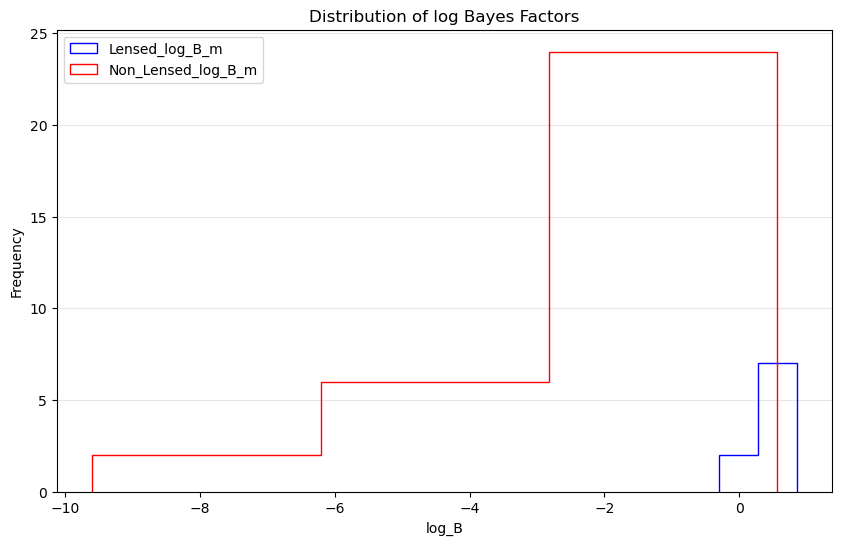

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
a= -10
df = pd.read_csv('../plots/bayes_factor_3d_results.csv')
df = df[(df['log_B'] > a) & (df['log_B_m'] > a)]

def lensed(row):
    # Split "3_0" by "_" to get ["3", "0"], then take the first part
    prefix_0 = row['Pair_0'].split('_')[0]
    prefix_1 = row['Pair_1'].split('_')[0]
    
    # If starting numbers match, it is Lensed
    return prefix_0 == prefix_1

df['lensed'] = df.apply(lensed, axis=1)
lensed_log_B_m = df[df['lensed'] == True]['log_B_m']
non_lensed_log_B_m = df[df['lensed'] == False]['log_B_m']

plt.figure(figsize=(10, 6))
plt.hist(lensed_log_B_m, bins=2, label='Lensed_log_B_m', color='blue',histtype='step')
plt.hist(non_lensed_log_B_m, bins=3, label='Non_Lensed_log_B_m', color='red',histtype='step')

plt.xlabel('log_B')
plt.ylabel('Frequency')
plt.title('Distribution of log Bayes Factors')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()
